# Deploying stocks model serving

Steps
* [Creating serving graph](#Creating-serving-graph)
* [Testing locally](#Testing-locally)
* [Deploying the serving graph](#Deploying-the-serving-graph)

In [6]:
import mlrun
import os

project = mlrun.get_or_create_project('stocks',user_project=True,context='src/')

> 2022-11-08 10:40:52,959 [info] loaded project stocks from MLRun DB


## Creating serving graph

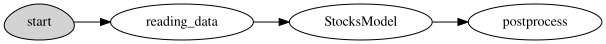

In [12]:
fn = mlrun.code_to_function('serving_stocks', kind='serving',image='mlrun/ml-models', filename='src/serving_stocks.py').apply(mlrun.auto_mount())

graph = fn.set_topology("flow", engine="async")
# Build the serving graph:
graph.to(handler='preprocess', name='reading_data')\
     .to(class_name="StocksModel", model_name='stocks_model', model_path=project.get_artifact_uri('stocks_model'))\
     .to(handler='postprocess',name='postprocess').respond()

fn.set_tracking()
#project.get_artifact_uri('stocks_model')
# 'store://models/stocks-dani/stocks_model'
fn.plot(rankdir="LR")

## Testing locally

In [13]:
server = fn.to_mock_server()

> 2022-11-08 10:45:16,328 [info] downloading v3io:///projects/stocks-dani/artifacts/train-stocks-model-handler/0/stocks_model_custom_objects_map.json.json to local temp file
> 2022-11-08 10:45:16,337 [info] downloading v3io:///projects/stocks-dani/artifacts/train-stocks-model-handler/0/stocks_model_custom_objects.zip.zip to local temp file
> 2022-11-08 10:45:24,119 [info] model StocksModel was loaded


In [14]:
import pandas as pd
response = server.test(body={"vector_name": 'stocks',
                             "start_time" : 59,
                             "end_time"   : 0,
                             "seq_size"   : 5})

pd.DataFrame(data=response[0], columns=response[1]).head()

,prediction,datetime,tickers,key,true
0,139.205932,2022-11-07 16:00:00,A,A 2022-11-07 16:00:00,138.029999
1,98.938188,2022-11-07 16:00:00,ABT,ABT 2022-11-07 16:00:00,99.500002
2,11.441755,2022-11-07 16:00:00,AAL,AAL 2022-11-07 16:00:00,14.319997
3,59.407850,2022-11-07 16:00:00,ACGL,ACGL 2022-11-07 16:00:00,58.009995
4,189.386736,2022-11-07 16:00:00,AAP,AAP 2022-11-07 16:00:00,183.089997


## Deploying the serving graph

In [15]:
fn.spec.readiness_timeout = 3600
address = fn.deploy()

> 2022-11-08 10:45:26,410 [info] Starting remote function deploy
2022-11-08 10:45:28  (info) Deploying function
2022-11-08 10:45:28  (info) Building
2022-11-08 10:45:28  (info) Staging files and preparing base images
2022-11-08 10:45:28  (info) Building processor image
2022-11-08 10:48:11  (info) Build complete
Failed to deploy. Details:

Error - NuclioFunction pod (nuclio-stocks-dani-serving-stocks-7c9c8f76d-hc8n2) is in a crash loop
    ...//nuclio/pkg/platform/kube/functionres/lazy.go:2391

Call stack:
NuclioFunction pod (nuclio-stocks-dani-serving-stocks-7c9c8f76d-hc8n2) is in a crash loop
    ...//nuclio/pkg/platform/kube/functionres/lazy.go:2391
NuclioFunction deployment failed
    ...//nuclio/pkg/platform/kube/functionres/lazy.go:558
Failed to wait for function deployment readiness
    ...//nuclio/pkg/platform/kube/functionres/lazy.go:351
Failed to wait for function resources to be available
    .../platform/kube/controller/nucliofunction.go:230

> 2022-11-08 10:48:33,531 [error

RunError: function serving-stocks deployment failed

We use the set_function on the project instance again to save the function's endpoint

In [ ]:
project.set_function(fn,name='serving_stocks')
project.save()

In [ ]:
import json
response = fn.invoke(path=address,
                     body={"vector_name": 'stocks',
                           "start_time" : 59,
                           "end_time"   : 0,
                           "seq_size"   : 5})

pd.DataFrame(data=response[0], columns=response[1])

## Scheduling the serving function

In [ ]:
body = {"vector_name": 'stocks',
        "start_time" : 59,
        "end_time"   : 0,
        "seq_size"   : 5}

# specifying '0 8 * * *' as schedule will trigger the function every day at 08:00 AM
fn = mlrun.code_to_function(name='prediction_kv',kind='job',image='mlrun/mlrun',handler='ingestion_service_invoker', filename='src/invoker.py')
fn.run(params={'endpoint':address, 'body': body}, schedule='*/10 * * * *')

In [ ]:
# Deleting the schedule (mark to test data ingestion flow)
# mlrun.get_run_db().delete_schedule(project.name,'prediction-kv-ingestion_service_invoker')